In [544]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import least_squares

In [545]:
# constants
R = 8.314 # J/molK

In [546]:
# define Toth model functions
def get_qs(T):
    return qs0 * np.exp(chi * (1 - T / T0)) # eq 9

def get_b(T):
    exponent = (-dH / (R * T0)) * ((T0 / T) - 1)
    return b0 * np.exp(exponent) # eq 10

def get_t(T):
    return t0 + alpha * (1 - (T0 / T)) # eq 11

def toth_isotherm(pressure, T):
    qs_val = get_qs(T)
    b_val = get_b(T)
    t_val = get_t(T)
    
    numerator = qs_val * b_val * pressure
    denominator = (1 + (b_val * pressure)**t_val)**(1 / t_val)
    
    return numerator / denominator # eq 8 (mol/kg) 


# define GAB isotherm equation for H2O
def gab_isotherm(x_h2o, params_gab): # x_h2o is RH from 0 to 1
    q_m, c, k_G = params_gab
    
    numerator = q_m * c * k_G * x_h2o
    
    term1 = 1 - k_G * x_h2o
    term2 = 1 + (c - 1) * k_G * x_h2o
    denominator = term1 * term2
    
    return numerator / denominator # eq 12


# define WADST model
import numpy as np

def wadst_model(P_co2, q_h2o, params_dry, params_wet, A):
    qs_d, b_d, t_d = params_dry
    qs_w, b_w, t_w = params_wet

    if q_h2o > 1e-9:
        weight = np.exp(-A / q_h2o)
    else:
        weight = 0.0

    # dry Toth term
    dry_term = (qs_d * b_d * P_co2) / ((1 + (b_d * P_co2)**t_d)**(1/t_d))

    # wet Toth term
    wet_term = (qs_w * b_w * P_co2) / ((1 + (b_w * P_co2)**t_w)**(1/t_w))

    q_total = (1 - weight) * dry_term + weight * wet_term # eq 13
    
    return q_total


# define CATSO model
def catso_model(P_co2, x_h2o, params_dry, params_wet, water_params):    
    qs_d, b_d, t_d = params_dry
    qs_w, b_w, t_w = params_wet
    b_h2o, S, K, x_m = water_params

    # competitive term (equation 15)
    denom_comp = (1 + (b_d * P_co2)**t_d + (b_h2o * x_h2o)**t_d)**(1/t_d)
    q_comp = (qs_d * b_d * P_co2) / denom_comp

    # theta function (equations 17 and 18)
    w_x = 1 / (1 + np.exp(-S * (x_h2o - x_m))) # eq 17
    theta_m = (1 - w_x) * K * x_h2o + w_x # eq 18

    # Toth isotherm for the wet sites
    denom_wet = (1 + (b_w * P_co2)**t_w)**(1/t_w)
    base_wet_q = (qs_w * b_w * P_co2) / denom_wet
    q_wet = theta_m * base_wet_q # eq 16

    # Total uptake
    q_total = q_comp + q_wet # eq 14
    
    return q_total

In [547]:
def toth_model(x, pressure, T):            
    qs_val = x[0] * np.exp(x[1] * (1.0 - (T / T0)))
    b_val  = x[2] * np.exp((-dH / (R * T0)) * ((T0 / T) - 1.0))
    t_val  = x[3] + x[4] * (1.0 - (T0 / T))

    q_star = (qs_val * b_val * pressure)/((1 + (b_val * pressure)**t_val)**(1 / t_val))

    return q_star

def residuals_toth(x, pressure, T, y_Toth):            
    q_pred = toth_model(x, pressure, T)
    return q_pred - y_Toth

In [548]:
# load in my .csv
dry_co2 = pd.read_csv('dry_co2.csv')

T0 = 313 #K
dH = -53970 # Joules (∆H)

pressures = dry_co2['pCO2 (bar)'].values * 100 # to put in kPa
Temps = dry_co2['Temp (K)'].values
y_values = dry_co2['CO2 Adsorption (mmol/g)'].values

x0 = [2.72, 0.01, 36.11, 0.25, 0.2]

results = least_squares(residuals_toth, x0, args=(pressures, Temps, y_values),
            bounds=([1, 0, 0, 0.001, 0.001,], [160, 5, np.inf, 1, 3]))
            #bounds=([1, 0.01, 0, 0.001, -10,], [160, 5, 100, 1, 10]))
            #bounds=([1, 0.01, 10, 0.001, 0.001,], [160, 5, 100, 1, 3]))

print("Success:", results.success)
print("Fitted Dry Parameters (x):", results.x)
print("Residual:", sum(results.fun**2))

Success: True
Fitted Dry Parameters (x): [2.65715293e+00 3.26284260e+00 1.96158714e+00 1.00000000e+00
 1.00000000e-03]
Residual: 0.3915023329226176


In [549]:
params_fitted = results.x
print(f"qs0 (Sat Capacity) : {params_fitted[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {params_fitted[1]:.4f}")
print(f"b0 (Affinity)      : {params_fitted[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {params_fitted[3]:.4f}")
print(f"alpha (Temp dep t) : {params_fitted[4]:.4f}")

qs0 (Sat Capacity) : 2.6572 mmol/g
chi (Temp dep qs)  : 3.2628
b0 (Affinity)      : 1.9616 kPa-1
t0 (Heterogeneity) : 1.0000
alpha (Temp dep t) : 0.0010


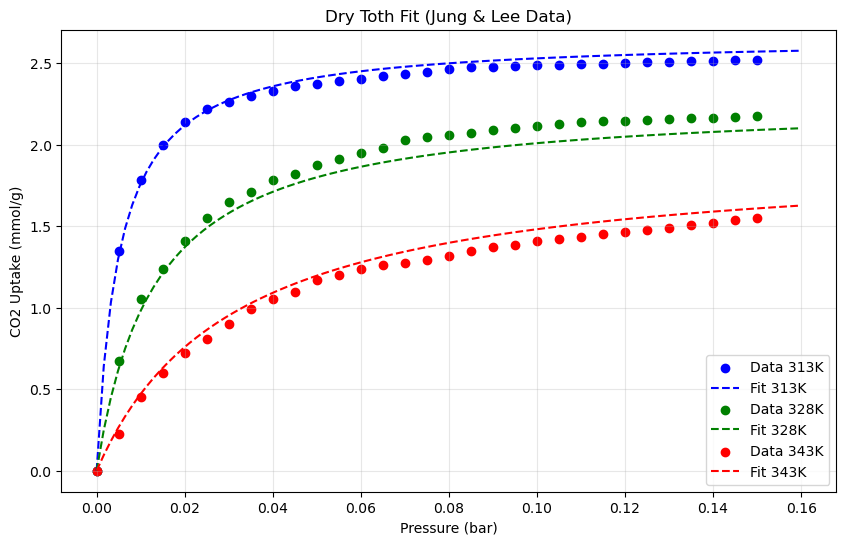

In [550]:
plt.figure(figsize=(10, 6))
colors = {313: 'blue', 328: 'green', 343: 'red'}

p_bar = np.linspace(0, 0.16, 100)
p_kPa = p_bar * 100

for T_val in [313, 328, 343]:
    # Raw data points
    subset = dry_co2[dry_co2['Temp (K)'] == T_val]
    plt.scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                color=colors[T_val], label=f'Data {T_val}K')
    
    # Fitted curve
    q_pred_curve = toth_model(params_fitted, p_kPa, T_val)
    plt.plot(p_bar, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')

plt.xlabel('Pressure (bar)')
plt.ylabel('CO2 Uptake (mmol/g)')
plt.title('Dry Toth Fit (Jung & Lee Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [551]:
# Try with more populated file of Jung & Lee
JLdry_co2_mod = pd.read_csv('JLdry_co2mod.csv')

T0 = 313 #K
dH = -53970 # Joules (∆H)

pressures = JLdry_co2_mod['pCO2 (bar)'].values * 100 # to put in kPa
Temps = JLdry_co2_mod['Temp (K)'].values
y_values = JLdry_co2_mod['CO2 Adsorption (mmol/g)'].values

x0 = [2.72, 0.01, 36.11, 0.25, 0.2]

results = least_squares(residuals_toth, x0, args=(pressures, Temps, y_values),
            bounds=([0, -np.inf, 0, 0, -np.inf,], [np.inf, np.inf, np.inf, 1, np.inf]))
            #bounds=([1, 0, 0, 0.001, 0.001,], [160, 5, np.inf, 1, 3]))
            #bounds=([1, 0.01, 0, 0.001, -10,], [160, 5, 100, 1, 10]))
            #bounds=([1, 0.01, 10, 0.001, 0.001,], [160, 5, 100, 1, 3]))

print("Success:", results.success)
print("Residual:", sum(results.fun**2))

params_fitted = results.x
print(f"qs0 (Sat Capacity) : {params_fitted[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {params_fitted[1]:.4f}")
print(f"b0 (Affinity)      : {params_fitted[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {params_fitted[3]:.4f}")
print(f"alpha (Temp dep t) : {params_fitted[4]:.4f}")

Success: True
Residual: 0.5881858695159686
qs0 (Sat Capacity) : 2.6604 mmol/g
chi (Temp dep qs)  : 0.2404
b0 (Affinity)      : 1.7922 kPa-1
t0 (Heterogeneity) : 1.0000
alpha (Temp dep t) : -3.8328


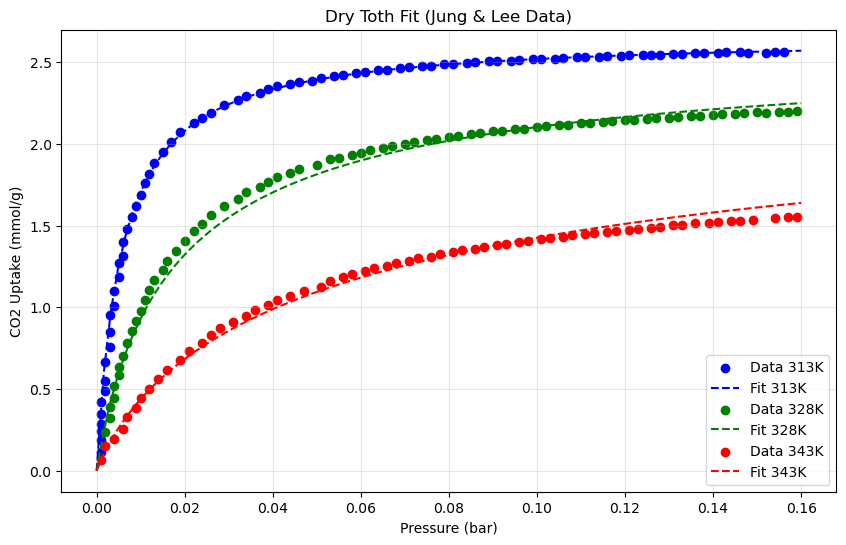

In [552]:
plt.figure(figsize=(10, 6))
colors = {313: 'blue', 328: 'green', 343: 'red'}

p_bar = np.linspace(0, 0.16, 100)
p_kPa = p_bar * 100

for T_val in [313, 328, 343]:
    # Raw data points
    subset = JLdry_co2_mod[JLdry_co2_mod['Temp (K)'] == T_val]
    plt.scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                color=colors[T_val], label=f'Data {T_val}K')
    
    # Fitted curve
    q_pred_curve = toth_model(params_fitted, p_kPa, T_val)
    plt.plot(p_bar, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')

plt.xlabel('Pressure (bar)')
plt.ylabel('CO2 Uptake (mmol/g)')
plt.title('Dry Toth Fit (Jung & Lee Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [553]:
# Try with raw data pts file of Jung & Lee
JLdry_co2_pts = pd.read_csv('JLdry_co2pts.csv')

T0 = 313 #K
dH = -53970 # Joules (∆H)

pressures = JLdry_co2_pts['pCO2 (bar)'].values * 100 # to put in kPa
Temps = JLdry_co2_pts['Temp (K)'].values
y_values = JLdry_co2_pts['CO2 Adsorption (mmol/g)'].values

x0 = [2.72, 0.01, 36.11, 0.25, 0.2]

results = least_squares(residuals_toth, x0, args=(pressures, Temps, y_values),
            #bounds=([-np.inf, -np.inf, -np.inf, -np.inf, -np.inf,], [np.inf, np.inf, np.inf, np.inf, np.inf]))
            #bounds=([0, -np.inf, 0, 0, -np.inf,], [np.inf, np.inf, np.inf, 1, np.inf]))
            #bounds=([1, 0, 0, 0.001, 0.001,], [160, 5, np.inf, 1, 3]))
            bounds=([1, 0.01, 0, 0.001, -10,], [160, 5, 100, 1, 10]))
            #bounds=([1, 0.01, 10, 0.001, 0.001,], [160, 5, 100, 1, 3]))

print("Success:", results.success)
print("Residual:", sum(results.fun**2))

params_fitted = results.x
print(f"qs0 (Sat Capacity) : {params_fitted[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {params_fitted[1]:.4f}")
print(f"b0 (Affinity)      : {params_fitted[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {params_fitted[3]:.4f}")
print(f"alpha (Temp dep t) : {params_fitted[4]:.4f}")

Success: True
Residual: 0.18206945864258806
qs0 (Sat Capacity) : 2.8608 mmol/g
chi (Temp dep qs)  : 0.0100
b0 (Affinity)      : 10.4670 kPa-1
t0 (Heterogeneity) : 0.5568
alpha (Temp dep t) : -1.8701


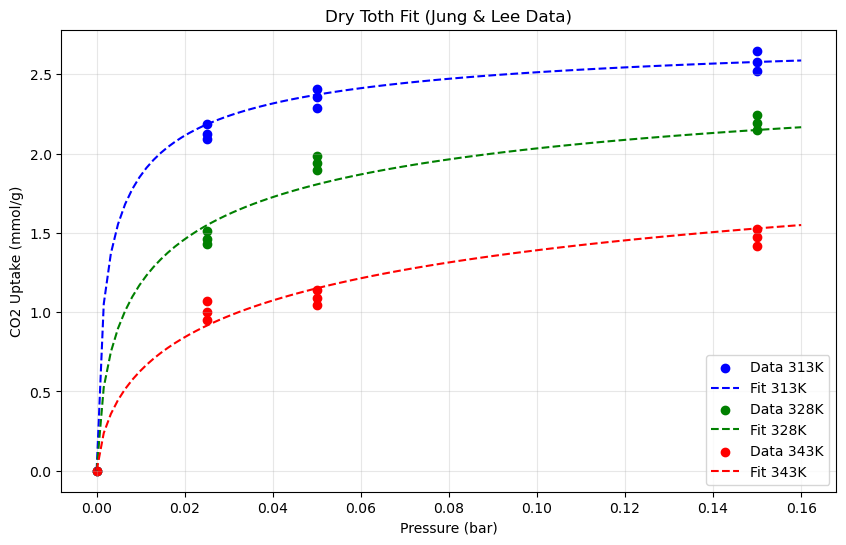

In [554]:
plt.figure(figsize=(10, 6))
colors = {313: 'blue', 328: 'green', 343: 'red'}

p_bar = np.linspace(0, 0.16, 100)
p_kPa = p_bar * 100

for T_val in [313, 328, 343]:
    # Raw data points
    subset = JLdry_co2_pts[JLdry_co2_pts['Temp (K)'] == T_val]
    plt.scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                color=colors[T_val], label=f'Data {T_val}K')
    
    # Fitted curve
    q_pred_curve = toth_model(params_fitted, p_kPa, T_val)
    plt.plot(p_bar, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')

plt.xlabel('Pressure (bar)')
plt.ylabel('CO2 Uptake (mmol/g)')
plt.title('Dry Toth Fit (Jung & Lee Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [555]:
# try with Darunte data
T0 = 298.15 # K
dH = -68300 # Joules (∆H)

files = [
    'Fig7-bottomheavy.csv', 
    'Fig7-100mbar.csv', 
    'Fig7-middleline.csv', 
    'Fig7-20mbar.csv'
]

# dictionary to store results
all_results = {}

# Initial guess and bounds
x0 = [2.72, 0.5, 36.11, 0.25, 0.2]
lower_bounds = [1.0, -5.0, 10, 0.001, -5.0]
upper_bounds = [160.0, 5.0, 100, 1.0, 5.0]

for file in files:
    Dar_dry_co2 = pd.read_csv(file)
    pressures = Dar_dry_co2['P_CO2 (mbar)'].values / 10 # to put in kPa
    Temps = Dar_dry_co2['Temp (K)'].values
    y_values = Dar_dry_co2['CO2 Adsorption (mmol/g)'].values

    res = least_squares(residuals_toth, x0, args=(pressures, Temps, y_values), bounds=(lower_bounds, upper_bounds))

    sse = np.sum(res.fun**2)
    
    # save to dictionary
    all_results[file] = {
        'success': res.success,
        'params': res.x,
        'SSE': sse
    }

    print(f"Results for {file}")
    print(f"Success: {res.success} | SSE: {sse:.4f}")
    print(f"qs0:   {res.x[0]:.4f}")
    print(f"chi:   {res.x[1]:.4f}")
    print(f"b0:    {res.x[2]:.4f}")
    print(f"t0:    {res.x[3]:.4f}")
    print(f"alpha: {res.x[4]:.4f}\n")

Results for Fig7-bottomheavy.csv
Success: True | SSE: 1.2705
qs0:   4.6508
chi:   5.0000
b0:    79.5059
t0:    0.2598
alpha: 1.1765

Results for Fig7-100mbar.csv
Success: True | SSE: 0.0518
qs0:   48.6815
chi:   3.6955
b0:    100.0000
t0:    0.1124
alpha: 0.2078

Results for Fig7-middleline.csv
Success: True | SSE: 0.4375
qs0:   4.9478
chi:   5.0000
b0:    62.2585
t0:    0.2525
alpha: 1.1450

Results for Fig7-20mbar.csv
Success: True | SSE: 1.2928
qs0:   4.2476
chi:   -3.5325
b0:    100.0000
t0:    0.2718
alpha: -0.5330



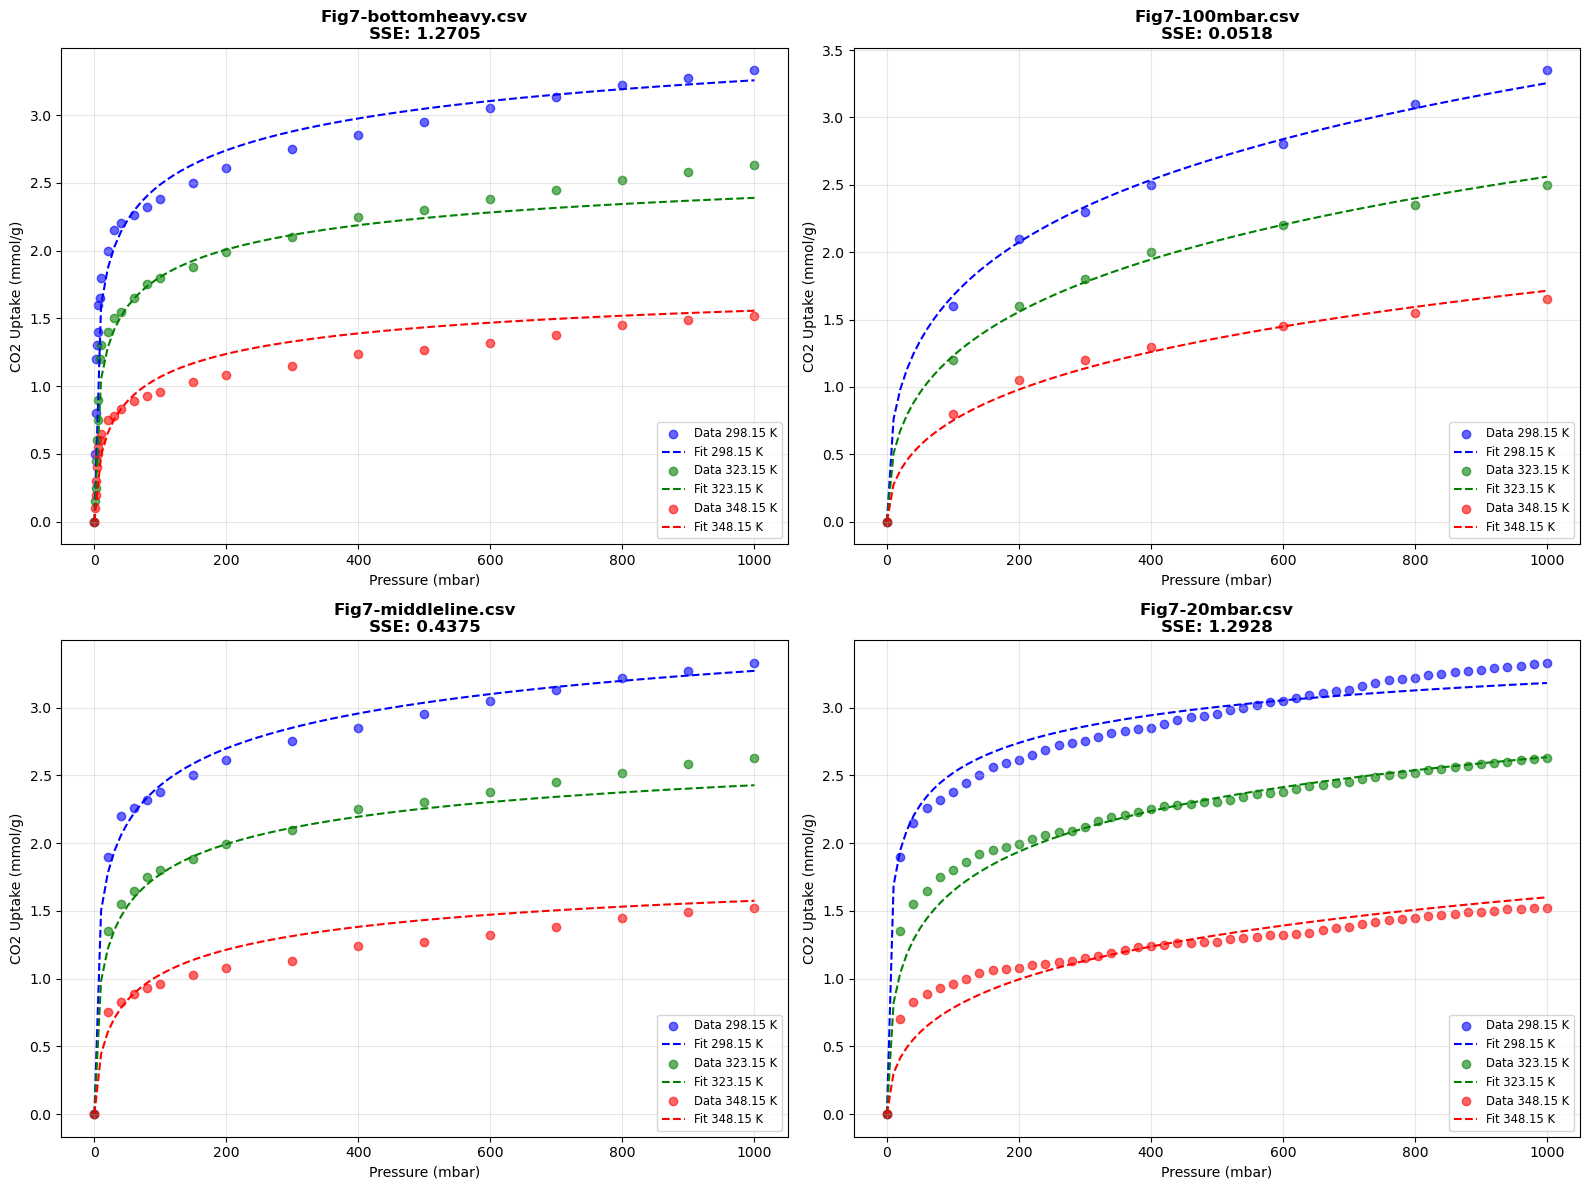

In [556]:
# 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = {298.15: 'blue', 323.15: 'green', 348.15: 'red'}
p_mbar = np.linspace(0, 1000, 100)
p_kPa = p_mbar / 10

for i, file in enumerate(files):
    ax = axes[i]
    
    Dar_dry_co2 = pd.read_csv(file)
    
    params_fitted = all_results[file]['params']
    sse = all_results[file]['SSE']
    
    for T_val in [298.15, 323.15, 348.15]:
        # Raw data points
        subset = Dar_dry_co2[Dar_dry_co2['Temp (K)'] == T_val]
        ax.scatter(subset['P_CO2 (mbar)'], subset['CO2 Adsorption (mmol/g)'], 
                   color=colors[T_val], label=f'Data {T_val} K', alpha=0.6)
        
        # Fitted curve
        q_pred_curve = toth_model(params_fitted, p_kPa, T_val)
        ax.plot(p_mbar, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val} K')

    ax.set_xlabel('Pressure (mbar)')
    ax.set_ylabel('CO2 Uptake (mmol/g)')
    
    ax.set_title(f'{file}\nSSE: {sse:.4f}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    ax.legend(fontsize='small', loc='lower right')

plt.tight_layout()
plt.show()

In [557]:
# Cut off Darunte data at 200 mbar
Dar_dry_co2 = pd.read_csv('Fig7-under200.csv')

T0 = 298.15 # K
dH = -68300 # Joules (∆H)

pressures = Dar_dry_co2['P_CO2 (mbar)'].values / 10 # to put in kPa
Temps = Dar_dry_co2['Temp (K)'].values
y_values = Dar_dry_co2['CO2 Adsorption (mmol/g)'].values

x0 = [2.72, 0.5, 36.11, 0.25, 0.2]

results = least_squares(residuals_toth, x0, args=(pressures, Temps, y_values),
            #bounds=([-np.inf, 0.0, -np.inf, -np.inf, -np.inf,], [np.inf, 0.000001, np.inf, np.inf, np.inf]))
            #bounds=([1, -5.0, 1, 0.001, -5,], [160, 5, 100, 1.0, 5]))
            bounds=([1, 0.01, 10, 0.001, 0.001,], [160, 5, 100, 1, 3]))

print("Success:", results.success)
print("Fitted Dry Parameters (x):", results.x)
print("Residual:", sum(results.fun**2))

Success: True
Fitted Dry Parameters (x): [ 3.68913539  4.99999999 44.15967005  0.32169466  1.91509764]
Residual: 0.8223618423603872


In [558]:
params_fitted = results.x
print(f"qs0 (Sat Capacity) : {params_fitted[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {params_fitted[1]:.4f}")
print(f"b0 (Affinity)      : {params_fitted[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {params_fitted[3]:.4f}")
print(f"alpha (Temp dep t) : {params_fitted[4]:.4f}")


qs0 (Sat Capacity) : 3.6891 mmol/g
chi (Temp dep qs)  : 5.0000
b0 (Affinity)      : 44.1597 kPa-1
t0 (Heterogeneity) : 0.3217
alpha (Temp dep t) : 1.9151


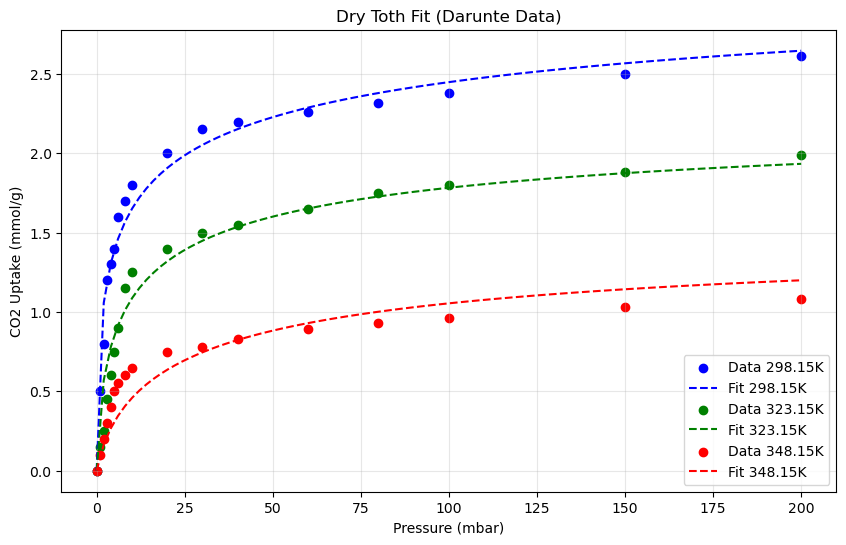

In [559]:
plt.figure(figsize=(10, 6))
colors = {298.15: 'blue', 323.15: 'green', 348.15: 'red'}

p_mbar = np.linspace(0, 200, 100)
p_kPa = p_mbar / 10

for T_val in [298.15, 323.15, 348.15]:
    # Raw data points
    subset = Dar_dry_co2[Dar_dry_co2['Temp (K)'] == T_val]
    plt.scatter(subset['P_CO2 (mbar)'], subset['CO2 Adsorption (mmol/g)'], 
                color=colors[T_val], label=f'Data {T_val}K')

    # Fitted curve
    q_pred_curve = toth_model(params_fitted, p_kPa, T_val)
    plt.plot(p_mbar, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')
    
plt.xlabel('Pressure (mbar)')
plt.ylabel('CO2 Uptake (mmol/g)')
plt.title('Dry Toth Fit (Darunte Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [560]:
# Wang and Lee paper
# load in my .csv
WL_dry_co2 = pd.read_csv('Wang_Lee_co2_trunc.csv')

T0 = 298.15 # K
dH = -69300 # Joules (∆H) two adsorption sites at 75.3 and 56.5 kJ/mol capacity weighted

pressures = WL_dry_co2['pCO2 (kPa)'].values # kPa
Temps = WL_dry_co2['Temp (K)'].values
y_values = WL_dry_co2['CO2 Adsorption (mmol/g)'].values

x0 = [2.72, 0.0, 36.11, 0.4, 0.1]

results = least_squares(residuals_toth, x0, args=(pressures, Temps, y_values),
            bounds=([-np.inf, -np.inf, -np.inf, -np.inf, -np.inf,], [np.inf, np.inf, np.inf, np.inf, np.inf]))
            #bounds=([1, -5.0, 1, 0.001, -5,], [160, 5, 100, 1.0, 5]))
            #bounds=([1, 0.01, 10, 0.001, 0.001,], [160, 5, 100, 1, 3]))
            #bounds=([1, 0.00, 10, 0.001, 0.001,], [160, 0.001, 100, 1, 3]))

print("Success:", results.success)
print("Fitted Dry Parameters (x):", results.x)
print("Residual:", sum(results.fun**2))

Success: True
Fitted Dry Parameters (x): [ 2.29097568e+00 -3.40257940e-01  9.96361953e+02  3.45759119e-01
 -1.18172161e-01]
Residual: 4.221292197253775


In [561]:
params_fitted = results.x
print(f"qs0 (Sat Capacity) : {params_fitted[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {params_fitted[1]:.4f}")
print(f"b0 (Affinity)      : {params_fitted[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {params_fitted[3]:.4f}")
print(f"alpha (Temp dep t) : {params_fitted[4]:.4f}")

qs0 (Sat Capacity) : 2.2910 mmol/g
chi (Temp dep qs)  : -0.3403
b0 (Affinity)      : 996.3620 kPa-1
t0 (Heterogeneity) : 0.3458
alpha (Temp dep t) : -0.1182


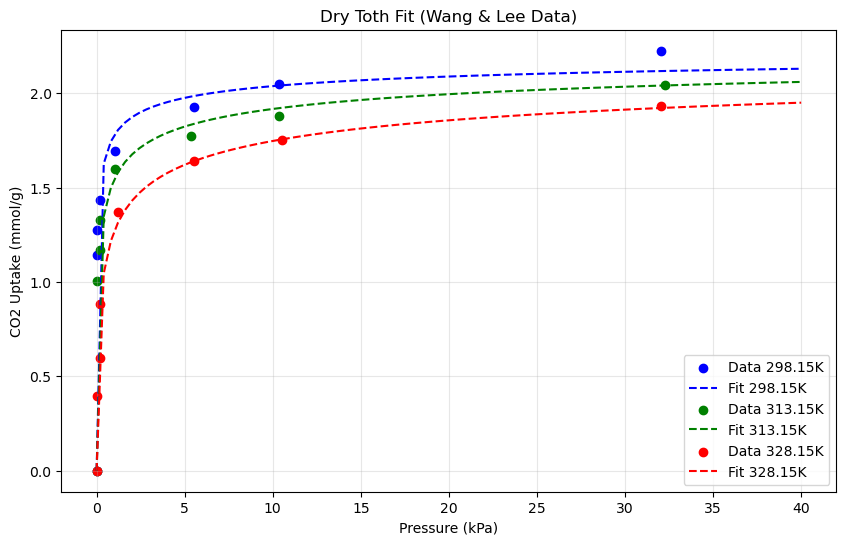

In [563]:
plt.figure(figsize=(10, 6))
colors = {298.15: 'blue', 313.15: 'green', 328.15: 'red'}

p_kPa = np.linspace(0, 40, 100)

for T_val in [298.15, 313.15, 328.15]:
    # Raw data points
    subset = WL_dry_co2[WL_dry_co2['Temp (K)'] == T_val]
    plt.scatter(subset['pCO2 (kPa)'], subset['CO2 Adsorption (mmol/g)'], 
                color=colors[T_val], label=f'Data {T_val}K')

    # Fitted curve
    q_pred_curve = toth_model(params_fitted, p_kPa, T_val)
    plt.plot(p_kPa, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')
    
plt.xlabel('Pressure (kPa)')
plt.ylabel('CO2 Uptake (mmol/g)')
plt.title('Dry Toth Fit (Wang & Lee Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [189]:
#run this
#check that x0 is within reasonable bounds
# dry fit parameters
# hold those constant
# fit GAB to get H2o parameters
# load in humidity curves (both humidities, need a new input in function RH)
# refit to get wet parameters

def GAB_model(x, RH):
    # x = [qm, c, kG]
    qm, c, kG = x
    numerator = x[0] * x[1] * x[2] * RH
    denom = (1 - x[2] * RH) * (1 + (x[1] - 1) * x[2] * RH)
    return numerator / denom

def residuals_GAB(x, RH, y_GAB):            
    q_h2o = GAB_model(x, RH)
    return q_h2o - y_GAB

In [190]:
# load in my .csv
gab_h2o = pd.read_csv('h2o_GAB_313K.csv')

pressures_h2o = gab_h2o['pH2O (bar)'].values * 100 # to put in kPa
Temps_h2o = gab_h2o['Temp (K)'].values
y_h2o = gab_h2o['Adsorption (mmol/g)'].values

# Calculate RH Using Clausius-Clapeyron
def get_RH(Temp,pH2O_kPa):
    Ps_Pa = 611.3 * np.exp(5417.1 * (1 / 273.15 - 1 / Temp))
    RH = (pH2O_kPa*1000) / Ps_Pa 
    return RH

RH = get_RH(Temps_h2o, pressures_h2o)

x0_h2o = [3.51, 2.73, 0.867]

results_h2o = least_squares(residuals_GAB, x0_h2o, args=(RH, y_h2o),
            bounds=([0, 0.01, 0], [np.inf, np.inf, 1]))

print("Success:", results_h2o.success)
print("Fitted Dry Parameters (x):", results_h2o.x)
print("Residual:", sum(results_h2o.fun))


Success: False
Fitted Dry Parameters (x): [2.77541643e+00 2.56120859e+03 1.39708074e-03]
Residual: 0.08481219514263189


In [191]:
params_h2o = results_h2o.x

print(f"qm (Monolayer) : {params_h2o[0]:.4f} mmol/g")
print(f"c  (Energy)    : {params_h2o[1]:.4f}")
print(f"kG (Multilayer): {params_h2o[2]:.4f}")

qm (Monolayer) : 2.7754 mmol/g
c  (Energy)    : 2561.2086
kG (Multilayer): 0.0014


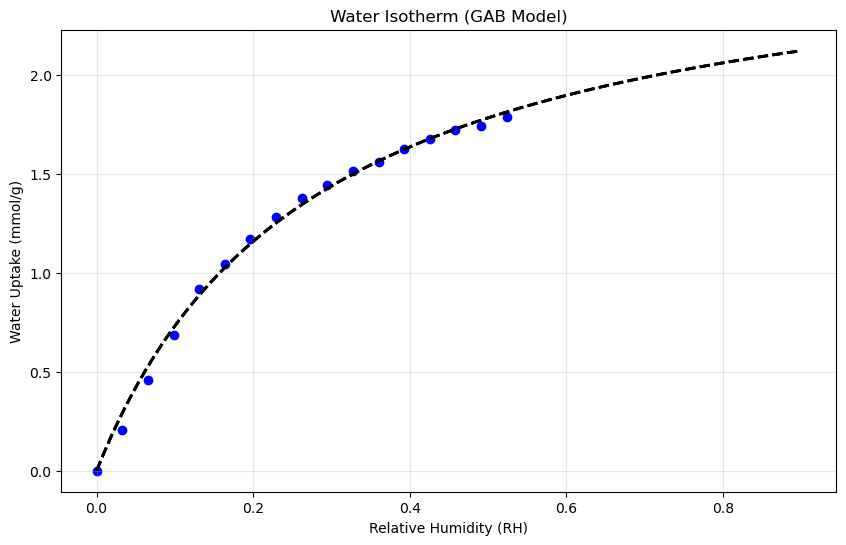

In [195]:
plt.figure(figsize=(10, 6))
colors = {313: 'blue', 328: 'green', 343: 'red'}

rh_smooth = np.linspace(0, 0.9, 100)

for T_val in [313, 328, 343]:
    # Raw data points
    mask = (Temps_h2o == T_val)
    plt.scatter(RH[mask], y_h2o[mask], 
                color=colors[T_val], label=f'Data {T_val}K')

    # Fitted Curve
    q_pred_gab = gab_model(params_h2o, rh_smooth)
    plt.plot(rh_smooth, q_pred_gab, 'k--', linewidth=2, label='GAB Fit')


plt.xlabel('Relative Humidity (RH)')
plt.ylabel('Water Uptake (mmol/g)')
plt.title('Water Isotherm (GAB Model)')
# plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

0.042556500000000004


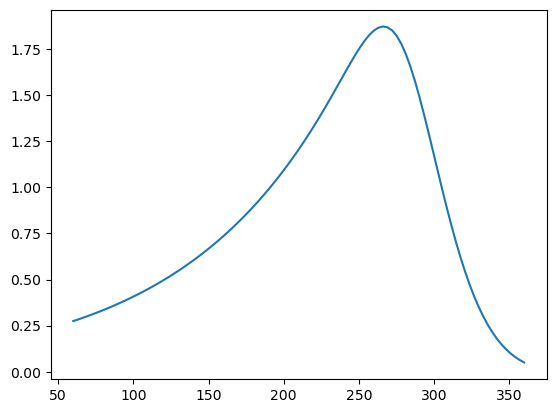

In [537]:
T = np.linspace(60,360,100)
T0 = 313 # K
p_Co2 = 420/1000000 * (101.325) # ppm to kPa

dH = -53970

#Bad
# qs0 = 2.6572
# chi = 3.2628
# b0 = 1.9616
# t0 = 1.0000
# alpha = 0.0010

#Bad
# qs0 = 2.5871
# chi = 0.0000
# b0 = 2.4597
# t0 = 0.9794
# alpha = -4.3626

#Bad
# qs0 = 2.6604
# chi = 0.2404
# b0 = 1.7922
# t0 = 1.0000
# alpha = -3.8328

#Better
qs0 = 3.3284
chi = -3.0860
b0 = 76.0440
t0 = 0.3436
alpha = -1.2472

#Bad
# qs0 = 2.8608
# chi = 0.0100
# b0 = 10.4670
# t0 = 0.5568
# alpha = -1.8701

test = toth_isotherm(p_Co2, T)

plt.plot(T,test)


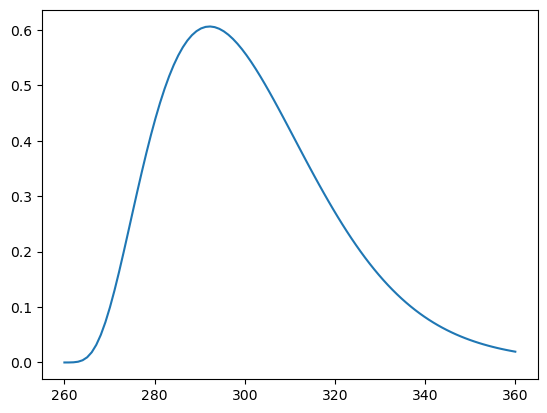

In [464]:
T = np.linspace(260,360,100)
T0 = 298.15 # K
p_Co2 = 420/1000000 * (101.325) # ppm to kPa

qs0 = 3.6891
chi = 5.0000
b0 = 44.1601
t0 = 0.3217
alpha = 1.9151
dH = -68300

test = toth_isotherm(p_Co2, T)

plt.plot(T,test)